# INEXUS Plots

This notebook generates three key plots for analyzing distributional effects of change in ridehail services using INEXUS (Rezaei et al., 2024).

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import datetime

# Set up the plotting style
sns.set_theme(style="whitegrid", 
              font_scale=3,
              rc={'figure.figsize':(20,14)})

# Set paths
path_output = 'plots/'

In [14]:
# Load data
df_lorenz = pd.read_csv('sf_2018_stacked_rh_fltsz_price_incRank_all.csv')

# Filter out price multiplier = 99.99
df_lorenz = df_lorenz.loc[df_lorenz['lever_position_price'] <= 99]

# Create pointer shortcuts for variables
price = 'lever_position_price'
fleetsize = 'lever_position_fltsz'
n_fleets = 'lever_n_fleets'

# Calculate baseline indicators
df_lorenz["baseline2YN"] = ((df_lorenz[price] == 1.0) & 
                            (df_lorenz[fleetsize] == 1.0) & 
                            (df_lorenz[n_fleets] == 2.0)).astype(int)

df_lorenz["baseline5YN"] = ((df_lorenz[price] == 1.0) & 
                            (df_lorenz[fleetsize] == 4.0) & 
                            (df_lorenz[n_fleets] == 5.0)).astype(int)

# Calculate INEXUS metrics
temp_varName = "Potential_INEXUS_in_dollar_2023_mean"

# For 5 fleets baseline
df_lorenz['temp_varName_baseOnly5'] = df_lorenz[temp_varName].where(df_lorenz['baseline5YN']==1)
df_lorenz['temp_varName_base5'] = df_lorenz.groupby(['incRank'])['temp_varName_baseOnly5'].transform('max')
df_lorenz['Potential INEXUS (rel. to 5 fleet baseline)'] = df_lorenz[temp_varName] - df_lorenz['temp_varName_base5']
df_lorenz['Potential INEXUS (pct rel. to 5 fleet baseline)'] = (df_lorenz[temp_varName] - df_lorenz['temp_varName_base5']) / (-df_lorenz['temp_varName_base5'])

# Create Income Deciles
rank_to_decile = {
    1: [1, 2],
    2: [3, 4],
    3: [5, 6],
    4: [7, 8],
    5: [9, 10],
    6: [11, 12],
    7: [13, 14],
    8: [15, 16],
    9: [17, 18],
    10: [19, 20]
}

df_lorenz['Income Deciles'] = 0
for decile, ranks in rank_to_decile.items():
    df_lorenz.loc[df_lorenz['incRank'].isin(ranks), 'Income Deciles'] = decile

## 1. INEXUS Percentage Change Plot

/var/folders/s0/c3wmlnq101j6d2dv5gj15fkm0000gn/T/ipykernel_50358/691758471.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  t_plot = sns.lineplot(data=graph_Data, x=x_var, y=y_var, ci=None, linewidth=6,


plots/Potential INEXUS (pct rel. to 5 fleet baseline)_Income Deciles_price_5fleets_4xfleetsize__12_08_2024_16_55_55


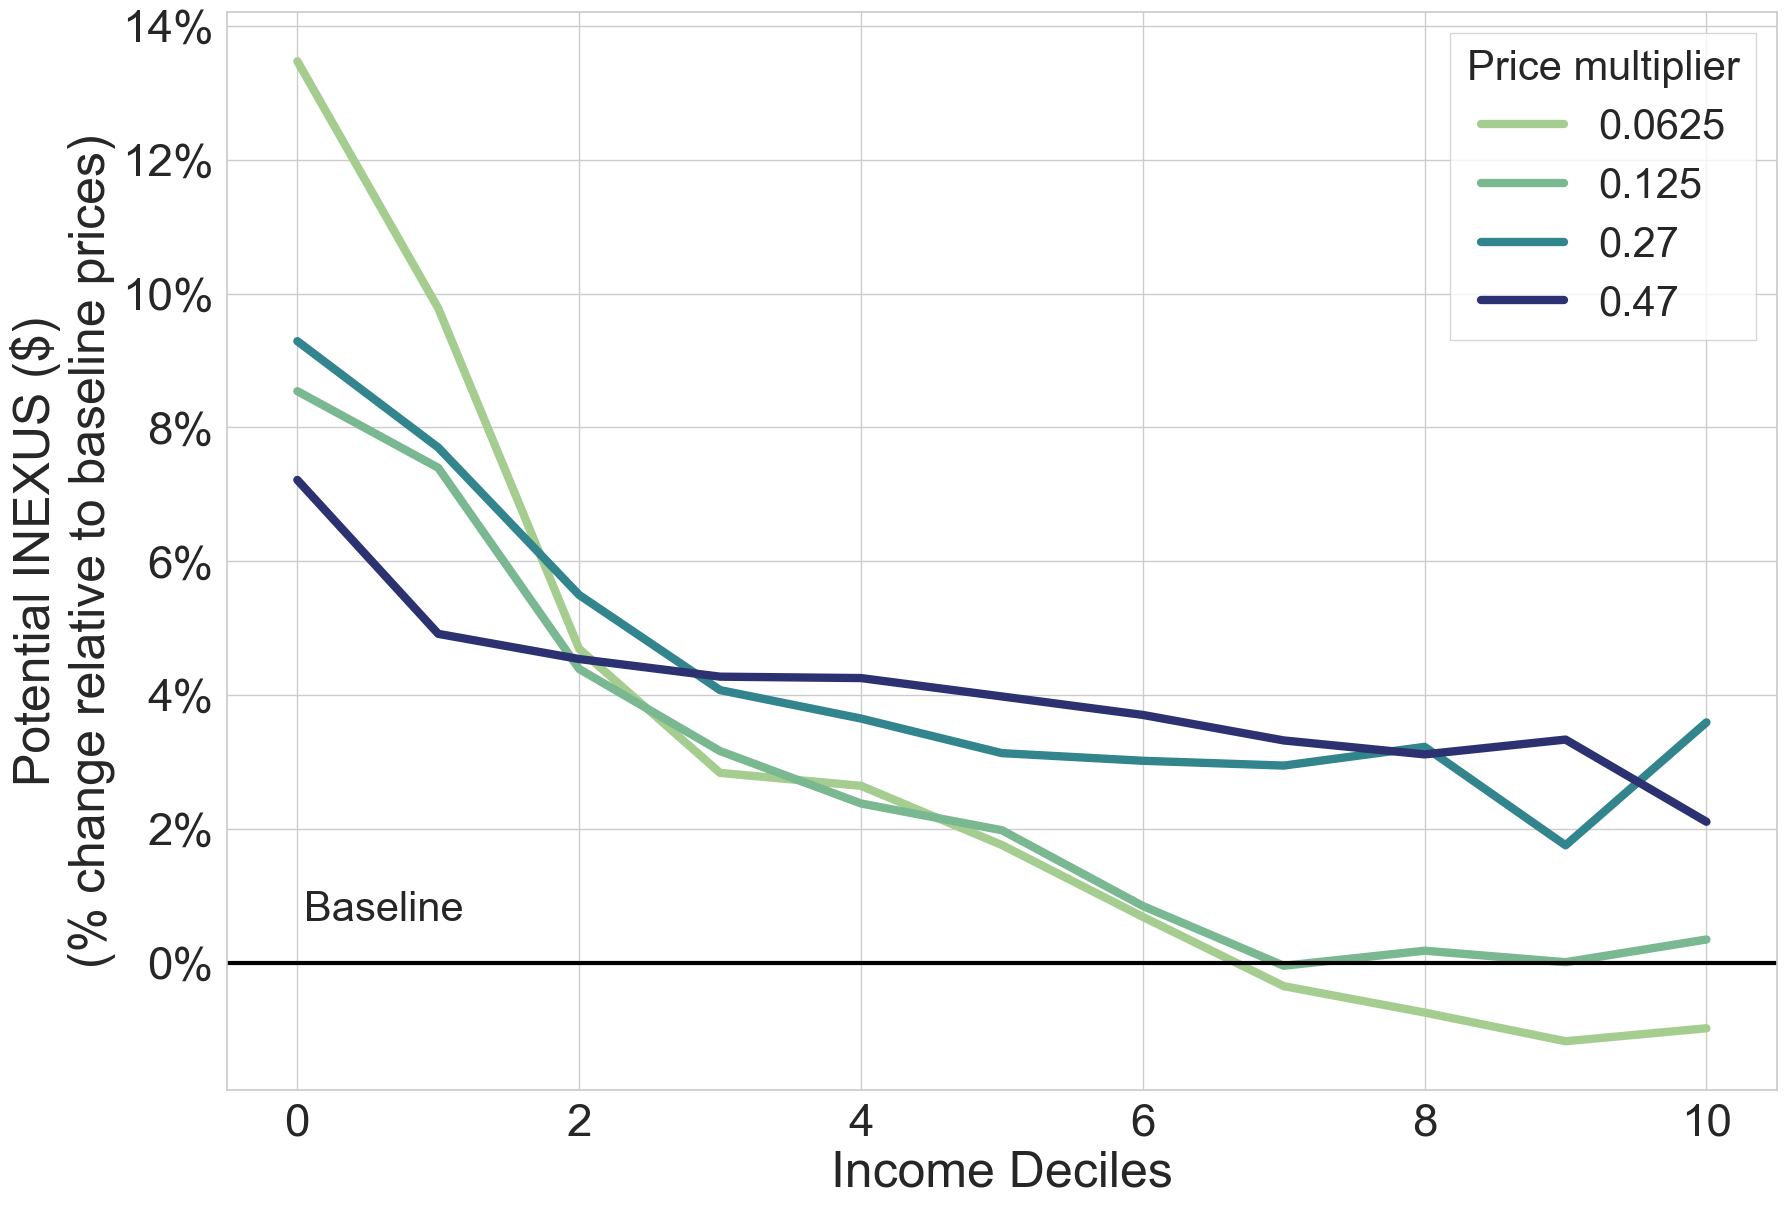

In [15]:
# Y var
y_var = 'Potential INEXUS (pct rel. to 5 fleet baseline)'

# X var
x_var = "Income Deciles"

# baseline
baseYN = "baseline5YN"
baselabel = 'Baseline: 5 Fleets'

# data
graph_Data = df_lorenz.loc[((df_lorenz[price] < 1) & 
                           (df_lorenz[fleetsize] == 4) &
                           ((df_lorenz[n_fleets] == 5) | 
                            (df_lorenz[n_fleets] == 0)))]

# Now Graph
t_plot = sns.lineplot(data=graph_Data, x=x_var, y=y_var, ci=None, linewidth=6,
                      hue=price,
                      palette='crest')

t_plot.yaxis.set_major_formatter(formatter='{:,.0%}'.format)
t_plot.set_ylabel('Potential INEXUS ($)\n(% change relative to baseline prices)')
t_plot.legend(title='Price multiplier', title_fontsize='small', fontsize='medium',
             fancybox=False, bbox_to_anchor=(1, 1), ncol=1, frameon=True,
             loc='upper right', prop={'size': 30})

# Add horizontal line at 0 with label 'Baseline'
t_plot.axhline(y=0, color='black', linestyle='-', linewidth=3)
t_plot.text(0.05, 0.15, 'Baseline', transform=t_plot.transAxes, fontsize=30, va='bottom')

# Save the plot
filename = path_output + y_var + "_" + x_var + "_price_5fleets_4xfleetsize__" + datetime.datetime.now().strftime('%m_%d_%Y_%H_%M_%S')
print(filename)
plt.savefig(filename + '.svg', format='svg')
plt.savefig(filename + '.png', dpi=300)

## 2. Ridehail Expenditure Plot

/var/folders/s0/c3wmlnq101j6d2dv5gj15fkm0000gn/T/ipykernel_50358/1802084174.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  t_plot = sns.barplot(data = graph_Data, x = x_var, y = y_var, ci=None,


plots/total_ridehail_expenditure_Income Deciles_price_5fleets_4xfleetsize__12_08_2024_16_55_56


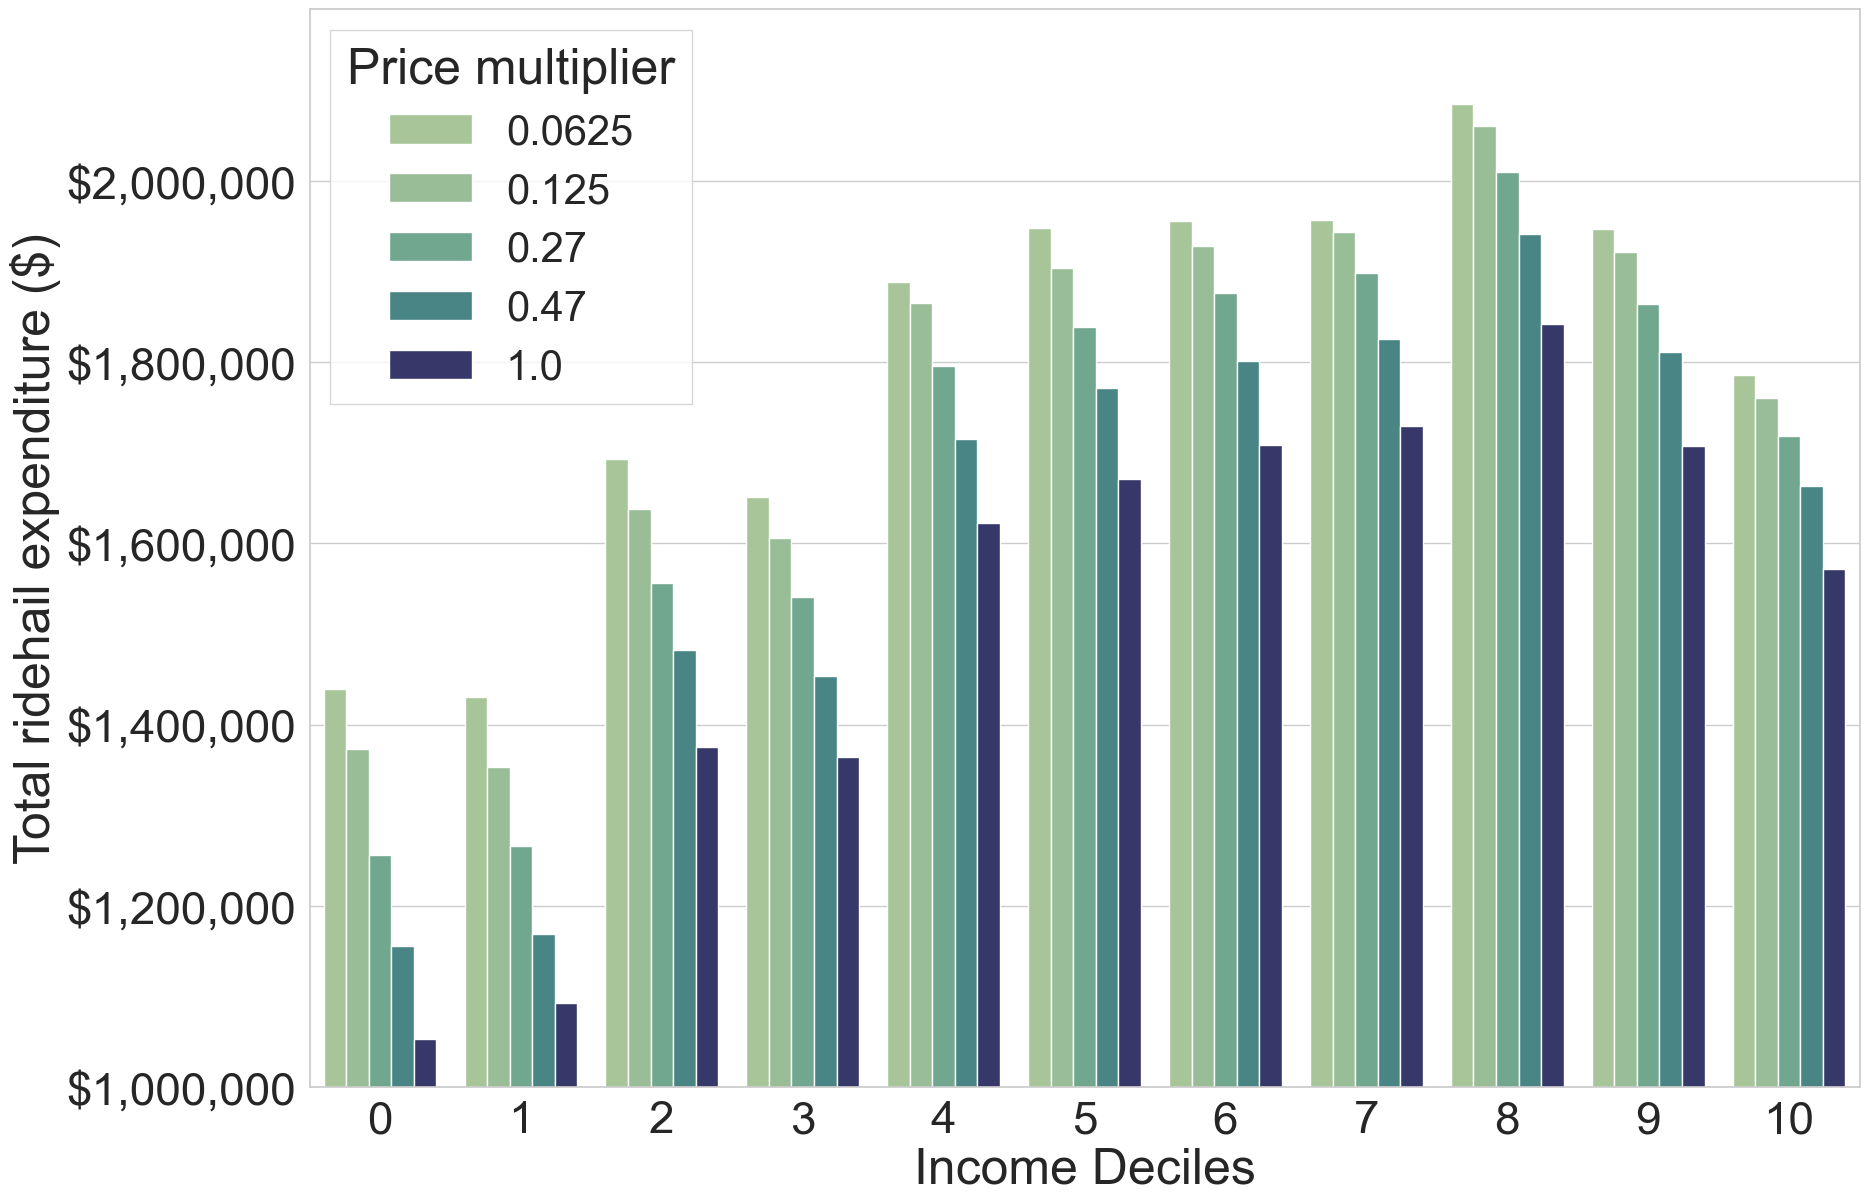

In [16]:
# Calculate total ridehail expenditure
df_lorenz['total_ridehail_expenditure'] = df_lorenz['cost_BEAM_sum'] * 3.3333

# Y var
y_var = 'total_ridehail_expenditure'

# X var
x_var = "Income Deciles"

# baseline
baseYN = "baseline5YN"
baselabel = 'Baseline: 5 Fleets'

# data
graph_Data = df_lorenz.loc[ ((df_lorenz[price]>=-1)&(df_lorenz[fleetsize]==4)
                           &((df_lorenz[n_fleets]==5)|(df_lorenz[n_fleets]==0)))
                          # | (df_lorenz[baseYN]== 1)                        
                          ]

# Now Graph
t_plot = sns.barplot(data = graph_Data, x = x_var, y = y_var, ci=None,
            hue = price, 
            palette = 'crest')

#t_plot = sns.barplot(data = df_lorenz.loc[(df_lorenz[baseYN]==1)], x = x_var, y = y_var, ci=None,
#            hue = baselabel,             
#            palette = 'Blues')

# Set the y-axis to start at $1,000,000
plt.ylim(1000000, None)

t_plot.set_ylabel('Total ridehail expenditure ($)')
t_plot.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: '${:,.0f}'.format(x)))
t_plot.legend(title='Price multiplier', fontsize='medium', fancybox=False,
             bbox_to_anchor=(0, 1), ncol=1, frameon=True,
             loc='upper left', prop={'size': 30})

# save
filename = path_output + y_var + "_" + x_var + "_price_5fleets_4xfleetsize__" + datetime.datetime.now().strftime('%m_%d_%Y_%H_%M_%S')
print(filename)
plt.savefig(filename + '.svg', format='svg')
plt.savefig(filename + '.png', dpi=300) # Nazanin -- 1000

## 3. Mode Share Plot

/var/folders/s0/c3wmlnq101j6d2dv5gj15fkm0000gn/T/ipykernel_50358/2362755744.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=graph_Data, x=price, y='Ridehail share (solo)',
/var/folders/s0/c3wmlnq101j6d2dv5gj15fkm0000gn/T/ipykernel_50358/2362755744.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=graph_Data, x=price, y='Ridehail share (pooled)',


plots/mode_shares_12_08_2024_16_55_58


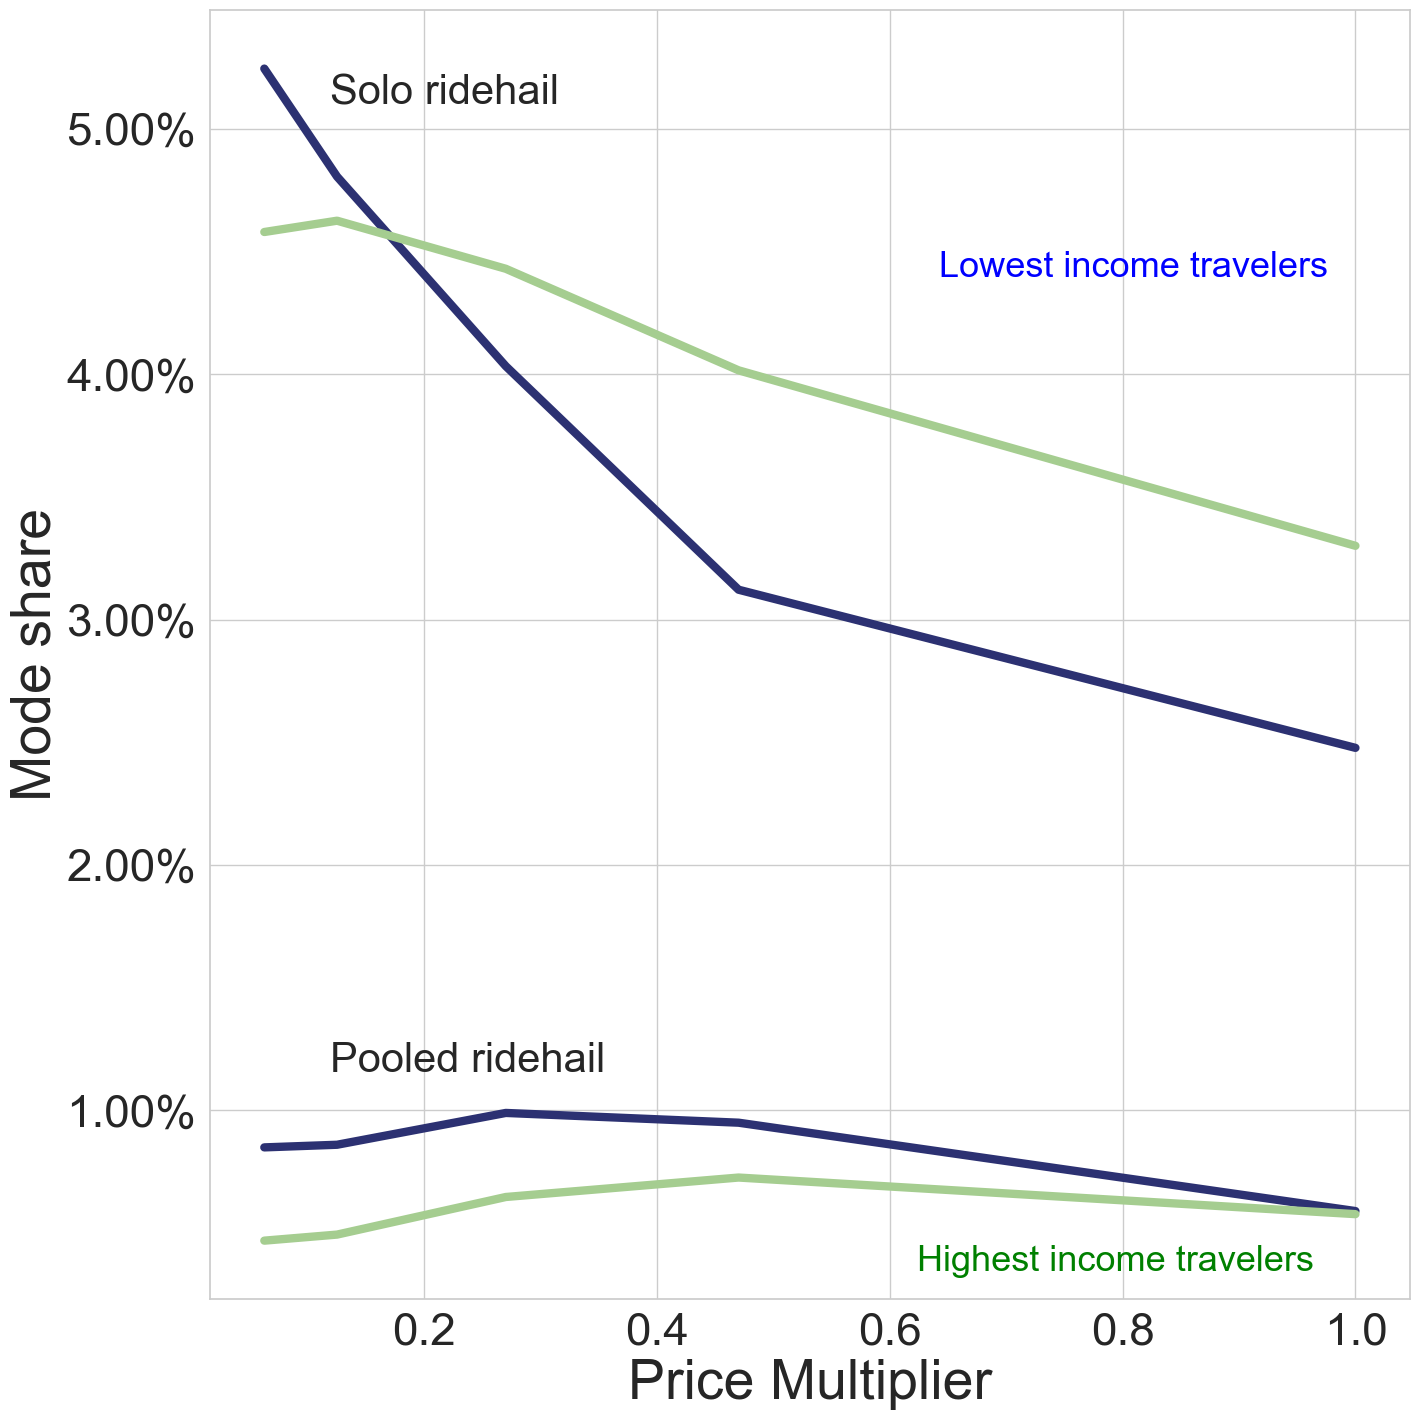

In [17]:
# Calculate ridehail shares
df_lorenz['Ridehail share (total)'] = df_lorenz['mode_ridehail_total_sum'] / df_lorenz['n_trips']
df_lorenz['Ridehail share (solo)'] = df_lorenz['mode_ride_hail_solo_sum'] / df_lorenz['n_trips']
df_lorenz['Ridehail share (pooled)'] = df_lorenz['mode_ride_hail_pooled_sum'] / df_lorenz['n_trips']

# Filter data
graph_Data = df_lorenz.loc[((df_lorenz[fleetsize] == 4) & 
                           (df_lorenz[n_fleets] == 5) &
                           (df_lorenz['Income Deciles'].isin([1, 10])))]

# Create figure
fig, ax = plt.subplots(figsize=(15, 15))

# Plot solo and pooled ridehail shares
sns.lineplot(data=graph_Data, x=price, y='Ridehail share (solo)', 
            ci=None, linewidth=6, hue='Income Deciles', style=n_fleets,
            palette='crest_r', ax=ax)

sns.lineplot(data=graph_Data, x=price, y='Ridehail share (pooled)', 
            ci=None, linewidth=6, hue='Income Deciles', style=n_fleets,
            palette='crest_r', ax=ax)

# Remove legend
ax.legend_.remove()

# Add labels
ax.text(0.1, 0.95, 'Solo ridehail', transform=ax.transAxes, fontsize=30, va='top')
ax.text(0.1, 0.17, 'Pooled ridehail', transform=ax.transAxes, fontsize=30, va='bottom')

# Add floating text
for i, (text, color) in enumerate([('Lowest income travelers', 'blue'), 
                                  ('Highest income travelers', 'green')]):
    x = graph_Data[price].max()
    y = graph_Data['Ridehail share (solo)'].iloc[-1] if i == 0 else graph_Data['Ridehail share (pooled)'].iloc[-1]
    x_offset = -300 if color == 'blue' else -30
    ax.annotate(text, xy=(x, y), xytext=(x_offset, -0.01), textcoords='offset points',
               color=color, fontsize=26, ha='left' if color == 'blue' else 'right', va='top')

# Format axes
ax.yaxis.set_major_formatter(formatter='{:,.2%}'.format)
ax.set_ylabel('Mode share', fontsize=40)
ax.set_xlabel('Price Multiplier', fontsize=40)

plt.tight_layout(pad=1.0)

# Save plot
filename = path_output + "mode_shares_" + datetime.datetime.now().strftime('%m_%d_%Y_%H_%M_%S')
print(filename)
plt.savefig(filename + '.svg', format='svg')
plt.savefig(filename + '.png', dpi=300)

plots/mode_shares_12_08_2024_16_59_07


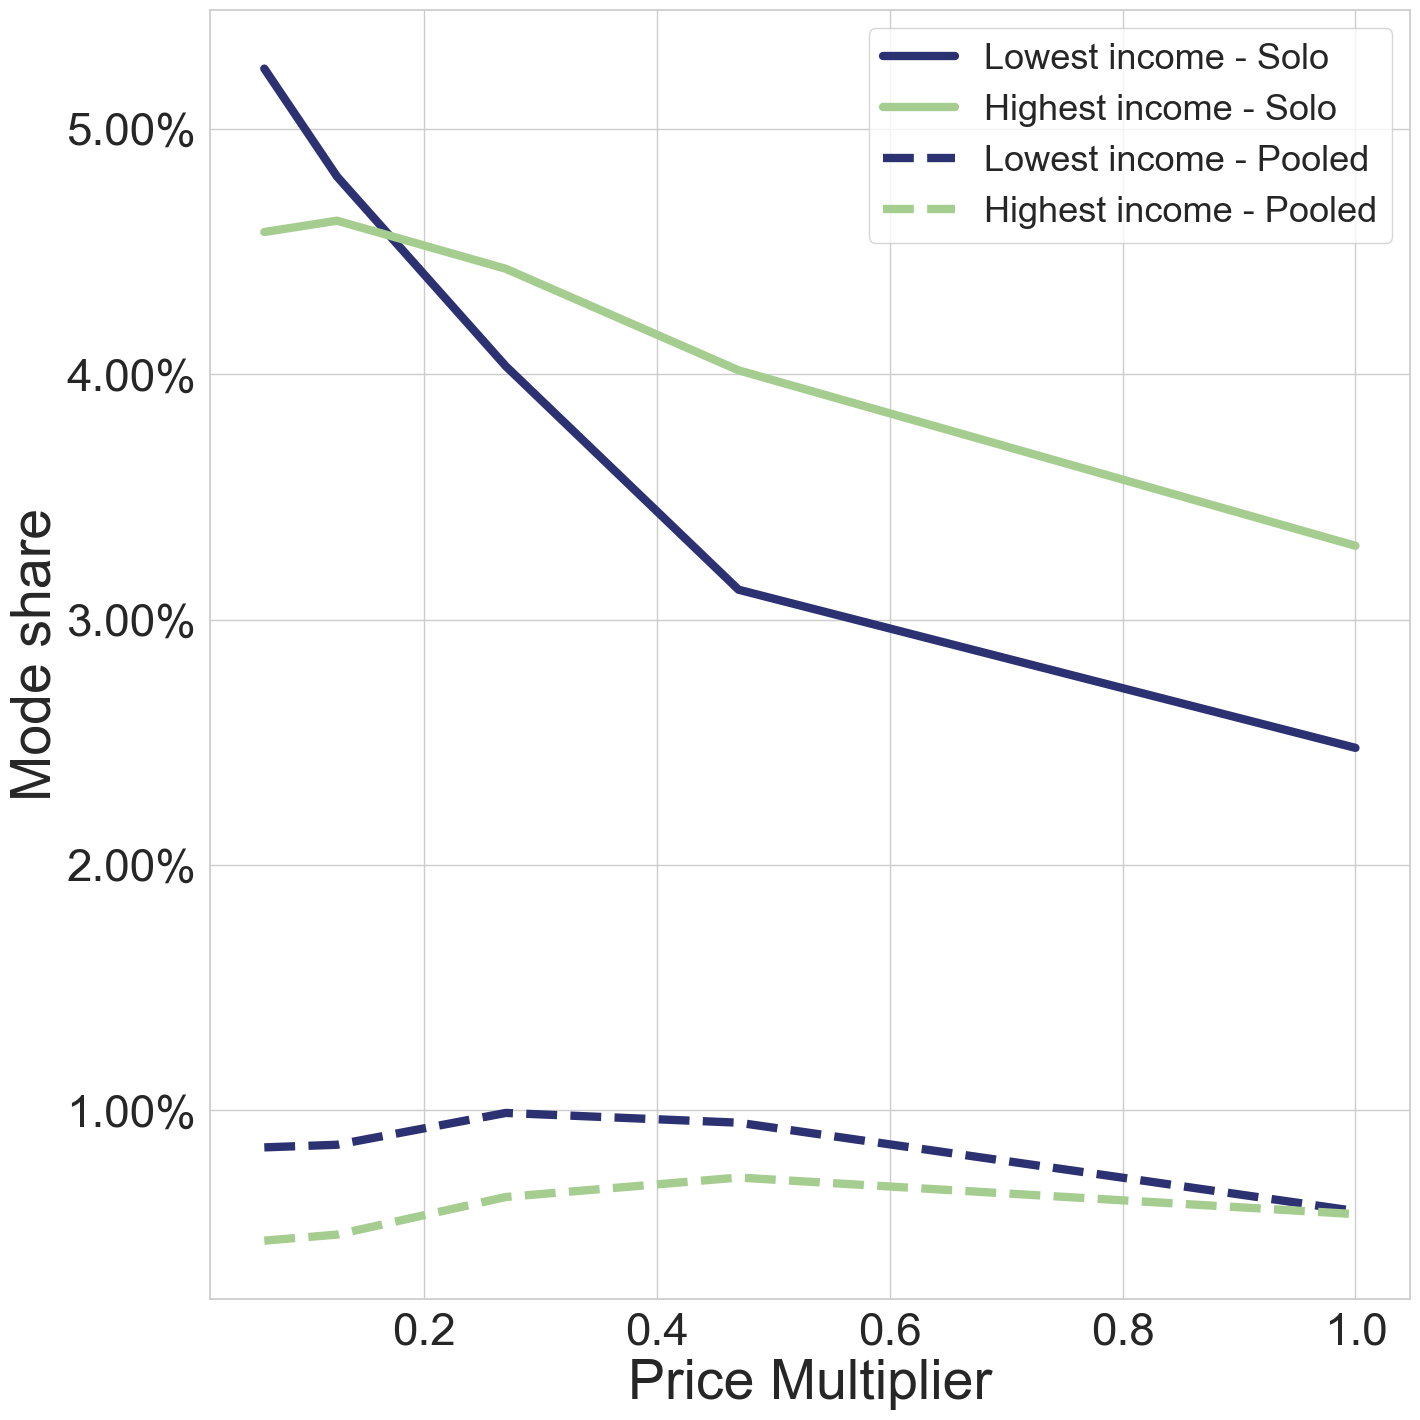

In [20]:
# Calculate ridehail shares
df_lorenz['Ridehail share (total)'] = df_lorenz['mode_ridehail_total_sum'] / df_lorenz['n_trips']
df_lorenz['Ridehail share (solo)'] = df_lorenz['mode_ride_hail_solo_sum'] / df_lorenz['n_trips']
df_lorenz['Ridehail share (pooled)'] = df_lorenz['mode_ride_hail_pooled_sum'] / df_lorenz['n_trips']

# Filter data
graph_Data = df_lorenz.loc[((df_lorenz[fleetsize] == 4) &
    (df_lorenz[n_fleets] == 5) &
    (df_lorenz['Income Deciles'].isin([1, 10])))]

# Create figure
fig, ax = plt.subplots(figsize=(15, 15))

# Plot solo ridehail shares
g1 = sns.lineplot(data=graph_Data, x=price, y='Ridehail share (solo)',
            errorbar=None, linewidth=6, hue='Income Deciles', 
            palette='crest_r', ax=ax)

# Plot pooled ridehail shares with dashed lines
g2 = sns.lineplot(data=graph_Data, x=price, y='Ridehail share (pooled)',
            errorbar=None, linewidth=6, hue='Income Deciles',
            palette='crest_r', ax=ax, linestyle='--')

# Modify legend
lines = ax.get_lines()
labels = ['Lowest income - Solo', 'Highest income - Solo',
          'Lowest income - Pooled', 'Highest income - Pooled']

# Create custom legend handles with appropriate line styles
legend_elements = [
    plt.Line2D([0], [0], color=lines[0].get_color(), linewidth=6, linestyle='-'),
    plt.Line2D([0], [0], color=lines[1].get_color(), linewidth=6, linestyle='-'),
    plt.Line2D([0], [0], color=lines[0].get_color(), linewidth=6, linestyle='--'),
    plt.Line2D([0], [0], color=lines[1].get_color(), linewidth=6, linestyle='--')
]

ax.legend(legend_elements, labels, fontsize=26, loc='upper right')

# Format axes
ax.yaxis.set_major_formatter(formatter='{:,.2%}'.format)
ax.set_ylabel('Mode share', fontsize=40)
ax.set_xlabel('Price Multiplier', fontsize=40)

plt.tight_layout(pad=1.0)

# Save plot
filename = path_output + "mode_shares_" + datetime.datetime.now().strftime('%m_%d_%Y_%H_%M_%S')
print(filename)
plt.savefig(filename + '.svg', format='svg')
plt.savefig(filename + '.png', dpi=300)